In [1]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import classification_report, f1_score, accuracy_score

from tensorflow import keras
from tensorflow.keras import layers
le = LabelEncoder()

In [2]:
# Reproducible seed
SEED = 8675309
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# File paths (Update to local directory)
path_data = Path("C:/Users/Andrew/Documents/GitHub/DAGE_Andrew/data_clean")

# Load apprehension dataset
survey = pd.read_csv(path_data/"survey_apprehension.csv")
display(survey.head())

,q_advice_text,biggest_fear
0,dont do things you dont want to do,solo_apprehension
1,just remember that they are probably just as n...,group_apprehension
2,just be yourself no one can blame you for bein...,group_apprehension
3,dont overthink the conversation the person you...,group_apprehension
4,i would tell my friend that its completely nor...,solo_apprehension


In [5]:
# Extract out "Equal"/NA observations
survey_na = survey[survey['biggest_fear'].isna()].copy()

# Keep only rows where biggest_fear is not NA
survey = survey[survey['biggest_fear'].notna()].copy()

# Create splits on non-equal observations
survey_train, survey_temp = train_test_split(
    survey,
    test_size=0.30,
    stratify=survey["biggest_fear"],
    random_state=SEED
)
survey_val, survey_test = train_test_split(
    survey_temp,
    test_size=0.50,
    stratify=survey_temp["biggest_fear"],
    random_state=SEED
)

# Remove temp object
del survey_temp

In [6]:
# Separate inputs/outputs
x_train = survey_train["q_advice_text"].astype(str).to_numpy()
x_val = survey_val["q_advice_text"].astype(str).to_numpy()
x_test = survey_test["q_advice_text"].astype(str).to_numpy()


y_train = le.fit_transform(survey_train["biggest_fear"])
y_val = le.transform(survey_val["biggest_fear"])
y_test = le.transform(survey_test["biggest_fear"])

num_classes = len(le.classes_)
print(f'Classes: {le.classes_}')

Classes: ['group_apprehension' 'solo_apprehension']


In [7]:
# Parameters for vectorization
max_tokens = 10000
sequence_length = 100

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length,
)

In [8]:
# Adapt vectorizer to training text
vectorizer.adapt(x_train)

In [9]:
# Transform inputs to vectors
x_train = vectorizer(x_train)
x_val = vectorizer(x_val)
x_test = vectorizer(x_test)

In [10]:
tf.random.set_seed(SEED)

model = keras.Sequential([
    # Specify that each input is a sequence of max_length token IDs
    layers.Input(shape=(max_tokens,)),

    # Embedding layer maps vocabulary tokens to 64-dimensional vectors
    layers.Embedding(input_dim=max_tokens, output_dim=64),

    # Average embeddings across the sequence length
    layers.GlobalAveragePooling1D(),

    # Fully connected layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Output layer
    layers.Dense(num_classes, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10000, 64)      │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,578 (2.47 MB)

 Trainable params: 648,578 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

This chunk is used to train the neural network. We will load pre-trained weights instead.

In [ ]:
#history = model.fit(
#    x_train, y_train,
#    validation_data=(x_val, y_val),
#    epochs=50,
#    batch_size=5
#)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5050 - loss: 0.6981 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5545 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5743 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5941 - loss: 0.6887 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5248 - loss: 0.6904 - val_accuracy: 0.4545 - val_loss: 0.6949
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5545 - loss: 0.6877 - val_accuracy: 0.4091 - val_loss: 0.6955
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5941 - loss: 0.6870 - val_accuracy: 0.4091 - val_loss: 0.6969
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7228 - loss: 0.6722 - val_accuracy: 0.4545 - val_loss

In [ ]:
# Save weights as h5 object
#model.save_weights(path_data/"apprehension_model.weights.h5")

# Save history as csv file/dataframe
#history_df = pd.DataFrame({
#    "training_loss": history.history["loss"],
#    "validation_loss": history.history["val_loss"],
#    "training_accuracy": history.history["accuracy"],
#    "validation_accuracy": history.history["val_accuracy"]
#})

#history_df.to_csv("training_history_apprehension.csv", index=False)

In [18]:
model.load_weights(path_data/"apprehension_model.weights.h5")
history = pd.read_csv(path_data/"training_history_apprehension.csv")

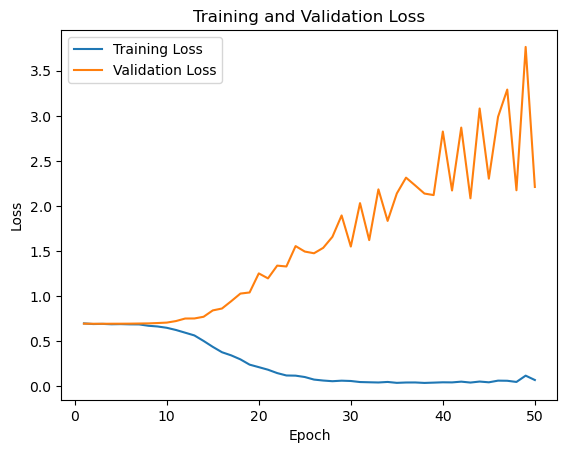

In [20]:
# Create epoch numbers starting at 1
epochs = range(1, len(history_df) + 1)

# Plot training and validation loss
plt.plot(
    epochs,
    history_df["training_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_df["validation_loss"],
    label="Validation Loss"
)

# Add labels and title
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

# Display legend and plot
plt.legend()
plt.show()

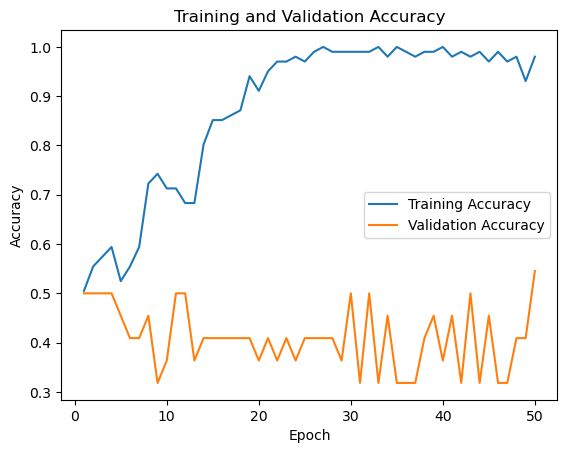

In [21]:
# Create epoch numbers starting at 1
epochs = range(1, len(history_df) + 1)

# Plot training and validation loss
plt.plot(
    epochs,
    history_df["training_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_df["validation_accuracy"],
    label="Validation Accuracy"
)

# Add labels and title
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

# Display legend and plot
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


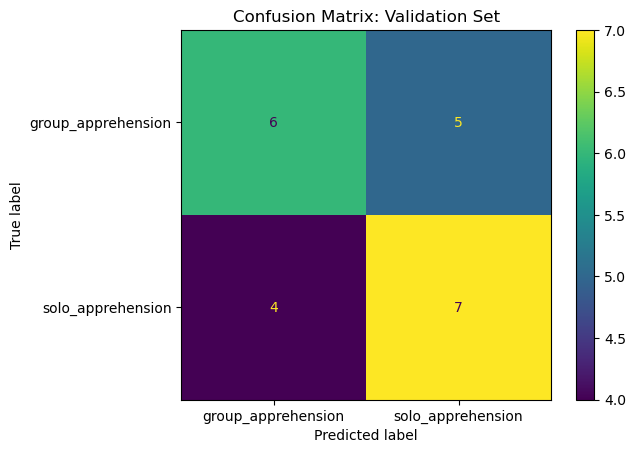

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Generate predicted probabilities
y_pred_probs = model.predict(x_val)

# Convert predicted probabilities to class indices
y_pred = np.argmax(
    np.asarray(y_pred_probs, dtype=np.float32),
    axis=1
)

# Ensure true labels are integer class indices
y_true = np.asarray(y_val, dtype=np.int64)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()

plt.title("Confusion Matrix: Validation Set")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


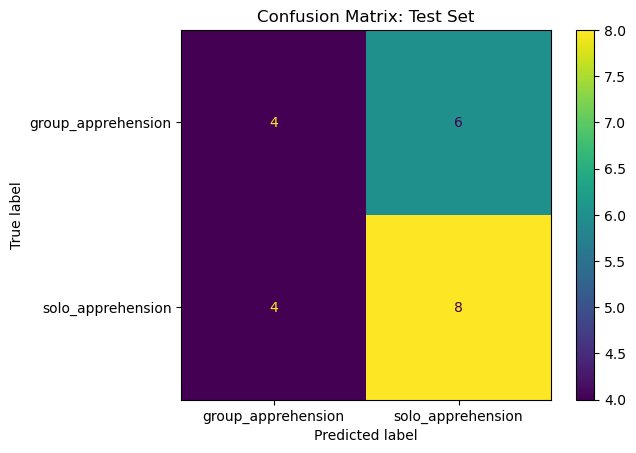

In [23]:
# Generate predicted probabilities
y_pred_probs = model.predict(x_test)

# Convert predicted probabilities to class indices
y_pred = np.argmax(
    np.asarray(y_pred_probs, dtype=np.float32),
    axis=1
)

# Ensure true labels are integer class indices
y_true = np.asarray(y_test, dtype=np.int64)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()

plt.title("Confusion Matrix: Test Set")
plt.show()